In [1]:
#Load packages
%matplotlib inline
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle,ConnectionPatch
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
from matplotlib.patches import FancyArrowPatch
import pandas as pd
typeface='Helvetica Neue'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22
mpl.rcParams['pdf.fonttype']=42

import os,glob
import numpy as np
import baltic as bt
import json
import csv

def hpd(data, level): #Thanks Gytis Dudas for this
    """
    Return highest posterior density interval from a list,
    given the percent posterior density interval required.
    """
    d = list(data)
    d.sort()

    nData = len(data)
    nIn = int(round(level * nData))
    if nIn < 2 :
        return None
    #raise RuntimeError("Not enough data. N data: %s"%(len(data)))
 
    i = 0
    r = d[i+nIn-1] - d[i]
    for k in range(len(d) - (nIn - 1)) :
        rk = d[k+nIn-1] - d[k]
        if rk < r :
            r = rk
            i = k

    assert 0 <= i <= i+nIn-1 < len(d)
 
    return (d[i], d[i+nIn-1])

def decimal_year_to_date(decimal_year):
    year = int(decimal_year)  # Get the integer part as the year
    remainder = decimal_year - year  # Get the decimal/fractional part
    start_of_year = pd.Timestamp(f'{year}-01-01')  # Start of the year
    # Calculate the date by adding the fractional part as days
    days_in_year = (pd.Timestamp(f'{year + 1}-01-01') - start_of_year).days
    date = start_of_year + pd.to_timedelta(remainder * days_in_year, unit='D')
    return date

/Users/ricardorivero/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


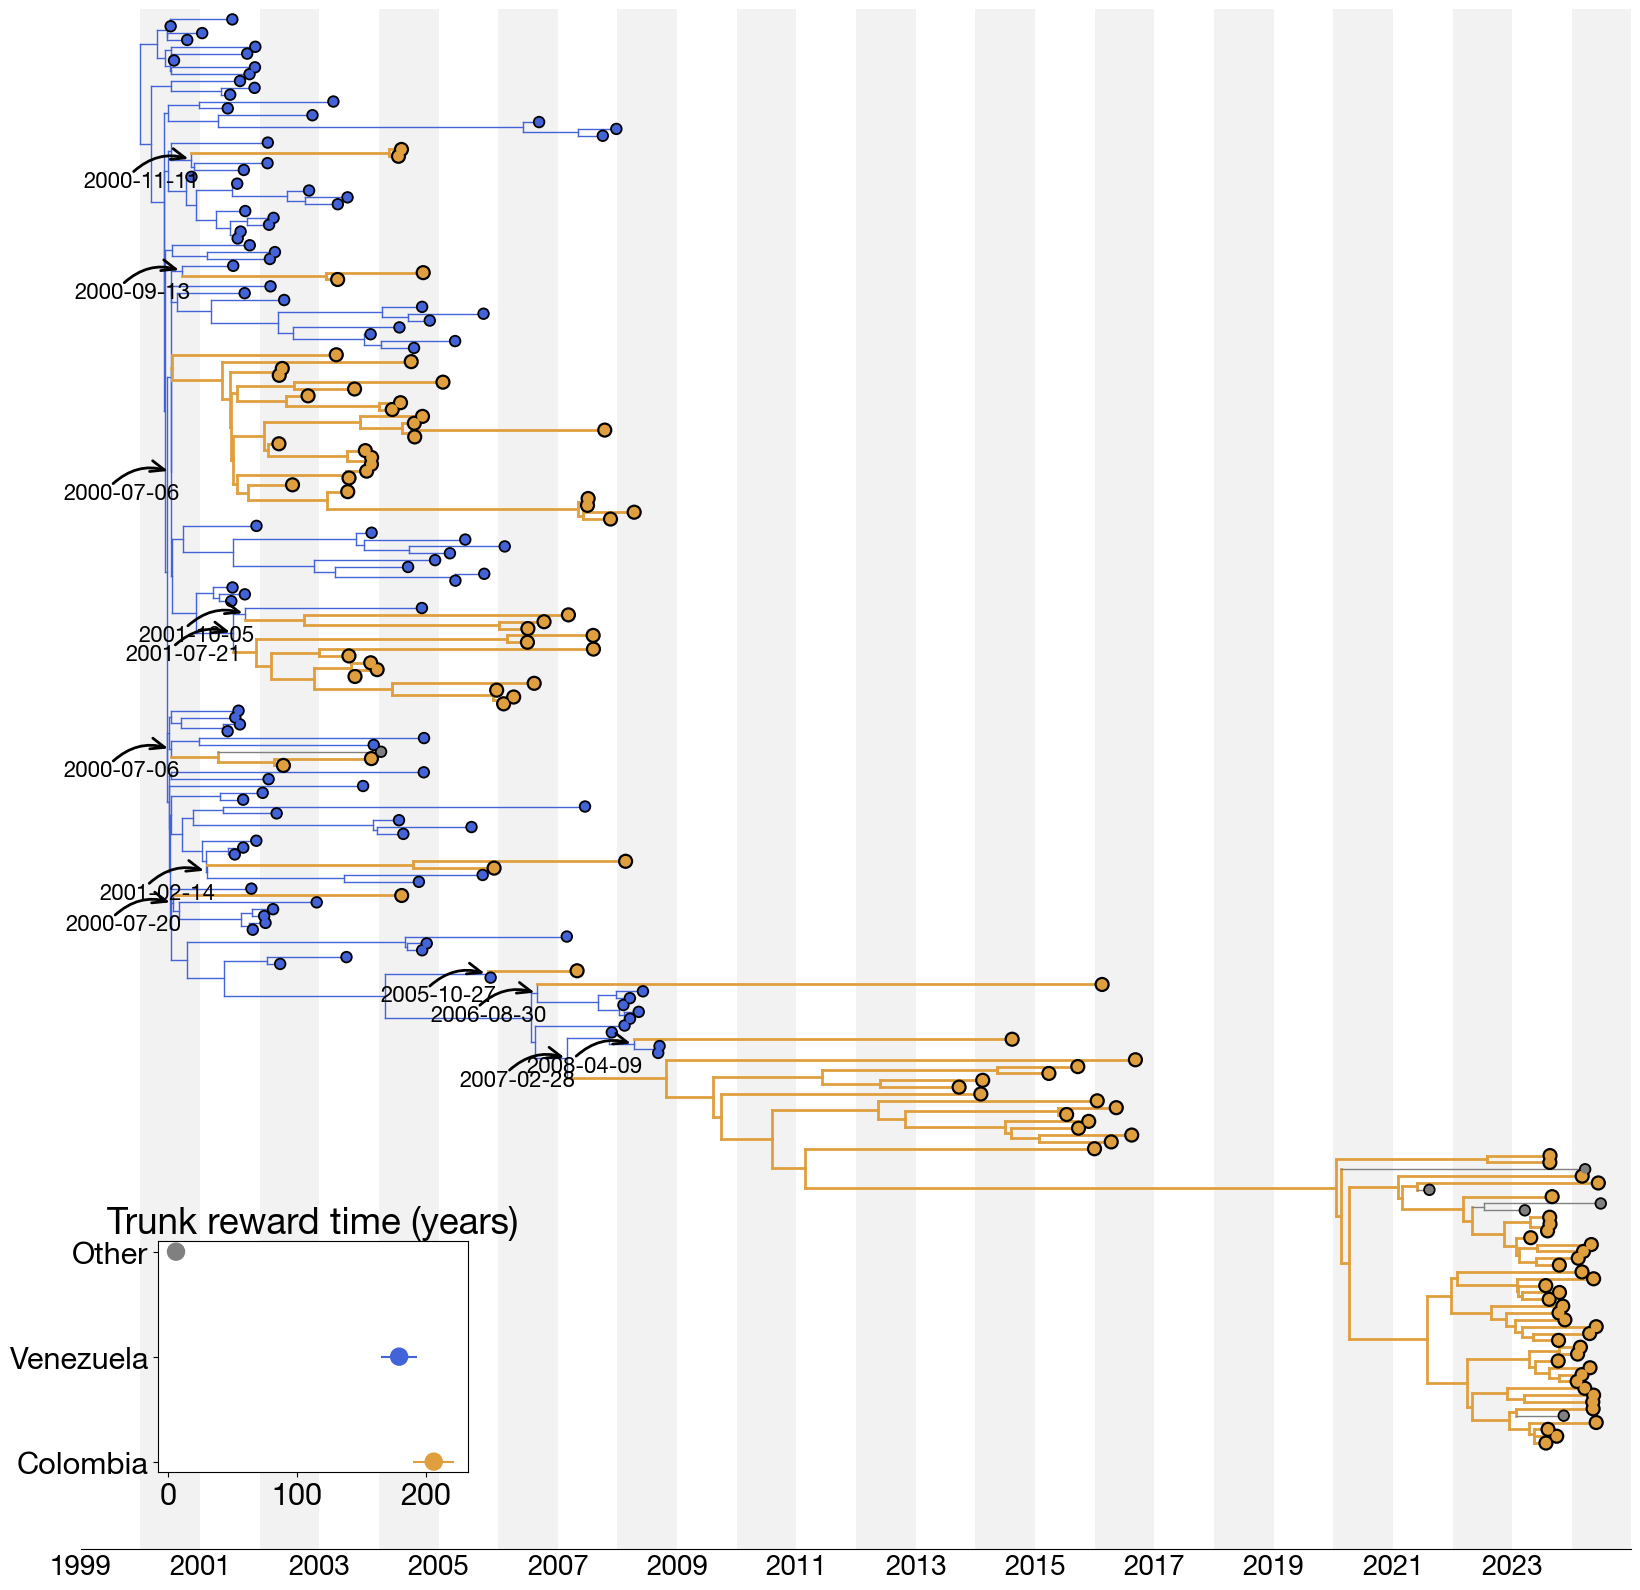

In [7]:
#Load tree
treePath = '/Users/ricardorivero/Documents/DENV/2024/D3/run2/D3_III_C1_markov.aligned.mcc.tree'
ll = bt.loadNexus(treePath, absoluteTime=True, sortBranches=True)

# Define color and label dictionaries
colors = {
    "Bolivia": "#c7522a",
    "Brazil": "#7e9c66",
    "Colombia": "#e09f3e",
    "Ecuador": "#335c67",
    "Paraguay": "#e29578",
    "Peru": "#3e909d",
    "USA": "#bd0a31",
    "Bangladesh": "#B56A7A",
    "Venezuela": "#4363d8",
    "Other": "grey"
}

# Function to detect introductions into Colombia
def introductions_into_colombia(k):
    return 'location' in k.traits and k.traits['location'] == 'Colombia'

def introductions_from_colombia(k):
    return 'location' in k.traits and k.traits['location'] != 'Colombia'

# Function to plot a curved arrow pointing to a node
def plot_curved_arrow(ax, start_x, start_y, end_x, end_y):
    arrow = FancyArrowPatch((start_x, start_y), (end_x, end_y), 
                            connectionstyle="arc3,rad=-0.3",  # Creates a curve
                            color='black', 
                            arrowstyle='->,head_length=10,head_width=4', lw=2, zorder = 1000)
    ax.add_patch(arrow)

# Function to get the coordinates for arrowhead at the node (introduction)


# Function to get the parent node coordinates (arrow start)
def get_parent_coordinates(node):
    parent = node.parent
    return parent.absoluteTime, parent.y

def other_coordinate(node):
    parent = node.parent
    return parent.absoluteTime -0.5, parent.y -0.5

# Visualization parameters
c_func = lambda k: colors[k.traits['location']] if 'location' in k.traits and k.traits['location'] in colors else '#FFCD00'
s_func = lambda k: 60 if k.traits['location'] == 'Colombia' else 40
line_func = lambda k: 2 if k.traits['location'] == 'Colombia' else 1

# Create the figure
fig, ax = plt.subplots(figsize=(20, 20), facecolor='w')

# Plot the tree
ll.plotTree(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, width=line_func)
ll.plotPoints(ax, x_attr=lambda k: k.absoluteTime, colour=c_func, size=s_func, zorder=1000)

#Record the dates of introductions into Colombia
introduction_dates = []

# Add curved arrows for introductions into Colombia, with annotation of time
for node in ll.Objects:
    if introductions_into_colombia(node) and node.parent and node.parent.traits['location'] != 'Colombia':
        # Get coordinates for arrow start and end
        end_x, end_y = get_parent_coordinates(node)
        start_x, start_y = other_coordinate(node)
        start_x = start_x - 0.5
        start_y = start_y - 1.5
        
        # Plot curved arrow
        plot_curved_arrow(ax, start_x, start_y, end_x, end_y)
        
        # Annotate the time of introduction (absoluteTime) next to the arrow
        introduction_time = decimal_year_to_date(round(node.parent.absoluteTime, 2))
        introduction_time = introduction_time.strftime('%Y-%m-%d')
        introduction_dates.append(introduction_time)
        ax.text(start_x - 0.8, start_y - 2, f'{introduction_time}', fontsize=16, color='black', ha='left', zorder = 1001)

# Add trunk rewards inset
axins = ax.inset_axes([0.05, 0.05, 0.2, 0.15])

# Create dataframe for rewards
data = [{'state': 'Colombia', 'median_reward': 206.1278, 'HPD95Hi_reward': 221.8457, 'HPD95Lo_reward': 189.6723},
        {'state': 'Other', 'median_reward': 6.329, 'HPD95Hi_reward': 9.4642, 'HPD95Lo_reward': 3.3638},
        {'state': 'Venezuela', 'median_reward': 179.3074, 'HPD95Hi_reward': 193.0045, 'HPD95Lo_reward': 165.034},
        ]
trunkRewards = pd.DataFrame(data)

# Sort the dataframe by 'median_reward'
trunkRewards = trunkRewards.sort_values(by='median_reward', ascending=False).reset_index(drop=True)

# Scatter plot for rewards
y_positions = range(len(trunkRewards))
axins.scatter(trunkRewards['median_reward'], y_positions, s=150, color=[colors[state] for state in trunkRewards['state']], zorder=1000)
axins.hlines(y=y_positions, xmin=trunkRewards['HPD95Lo_reward'], xmax=trunkRewards['HPD95Hi_reward'], color=[colors[state] for state in trunkRewards['state']], zorder=1000)
axins.set_yticks(y_positions)
axins.set_yticklabels(trunkRewards['state'])
axins.set_xlabel('')
axins.set_title('Trunk reward time (years)')

# Add aesthetic adjustments
years = np.arange(1999, 2025, 2)
plt.xticks(years, labels=[str(int(year)) for year in years])
[ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
ax.tick_params(axis='x', size=0, labelsize=20)
ax.tick_params(axis='y', size=0, labelsize=0)
ax.set_yticks([]) 
ax.set_yticklabels([])
[ax.axvspan(x, x+1, fc='k', ec='none', alpha=0.05, zorder=0) for x in range(1999, 2026, 1) if x % 2 == 0]

ax.set_xlim(1999, ll.mostRecent + 0.5)
ax.set_ylim(-15, len(ll.getExternal()) + 1)

# Save the figure
resolutionValue = 1200
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D3/Figures/DTA_D3_C2.jpeg', dpi=resolutionValue, bbox_inches='tight')
plt.savefig('/Users/ricardorivero/Documents/DENV/2024/D3/Figures/DTA_D3_C2.svg', dpi=resolutionValue, bbox_inches='tight')
plt.show()

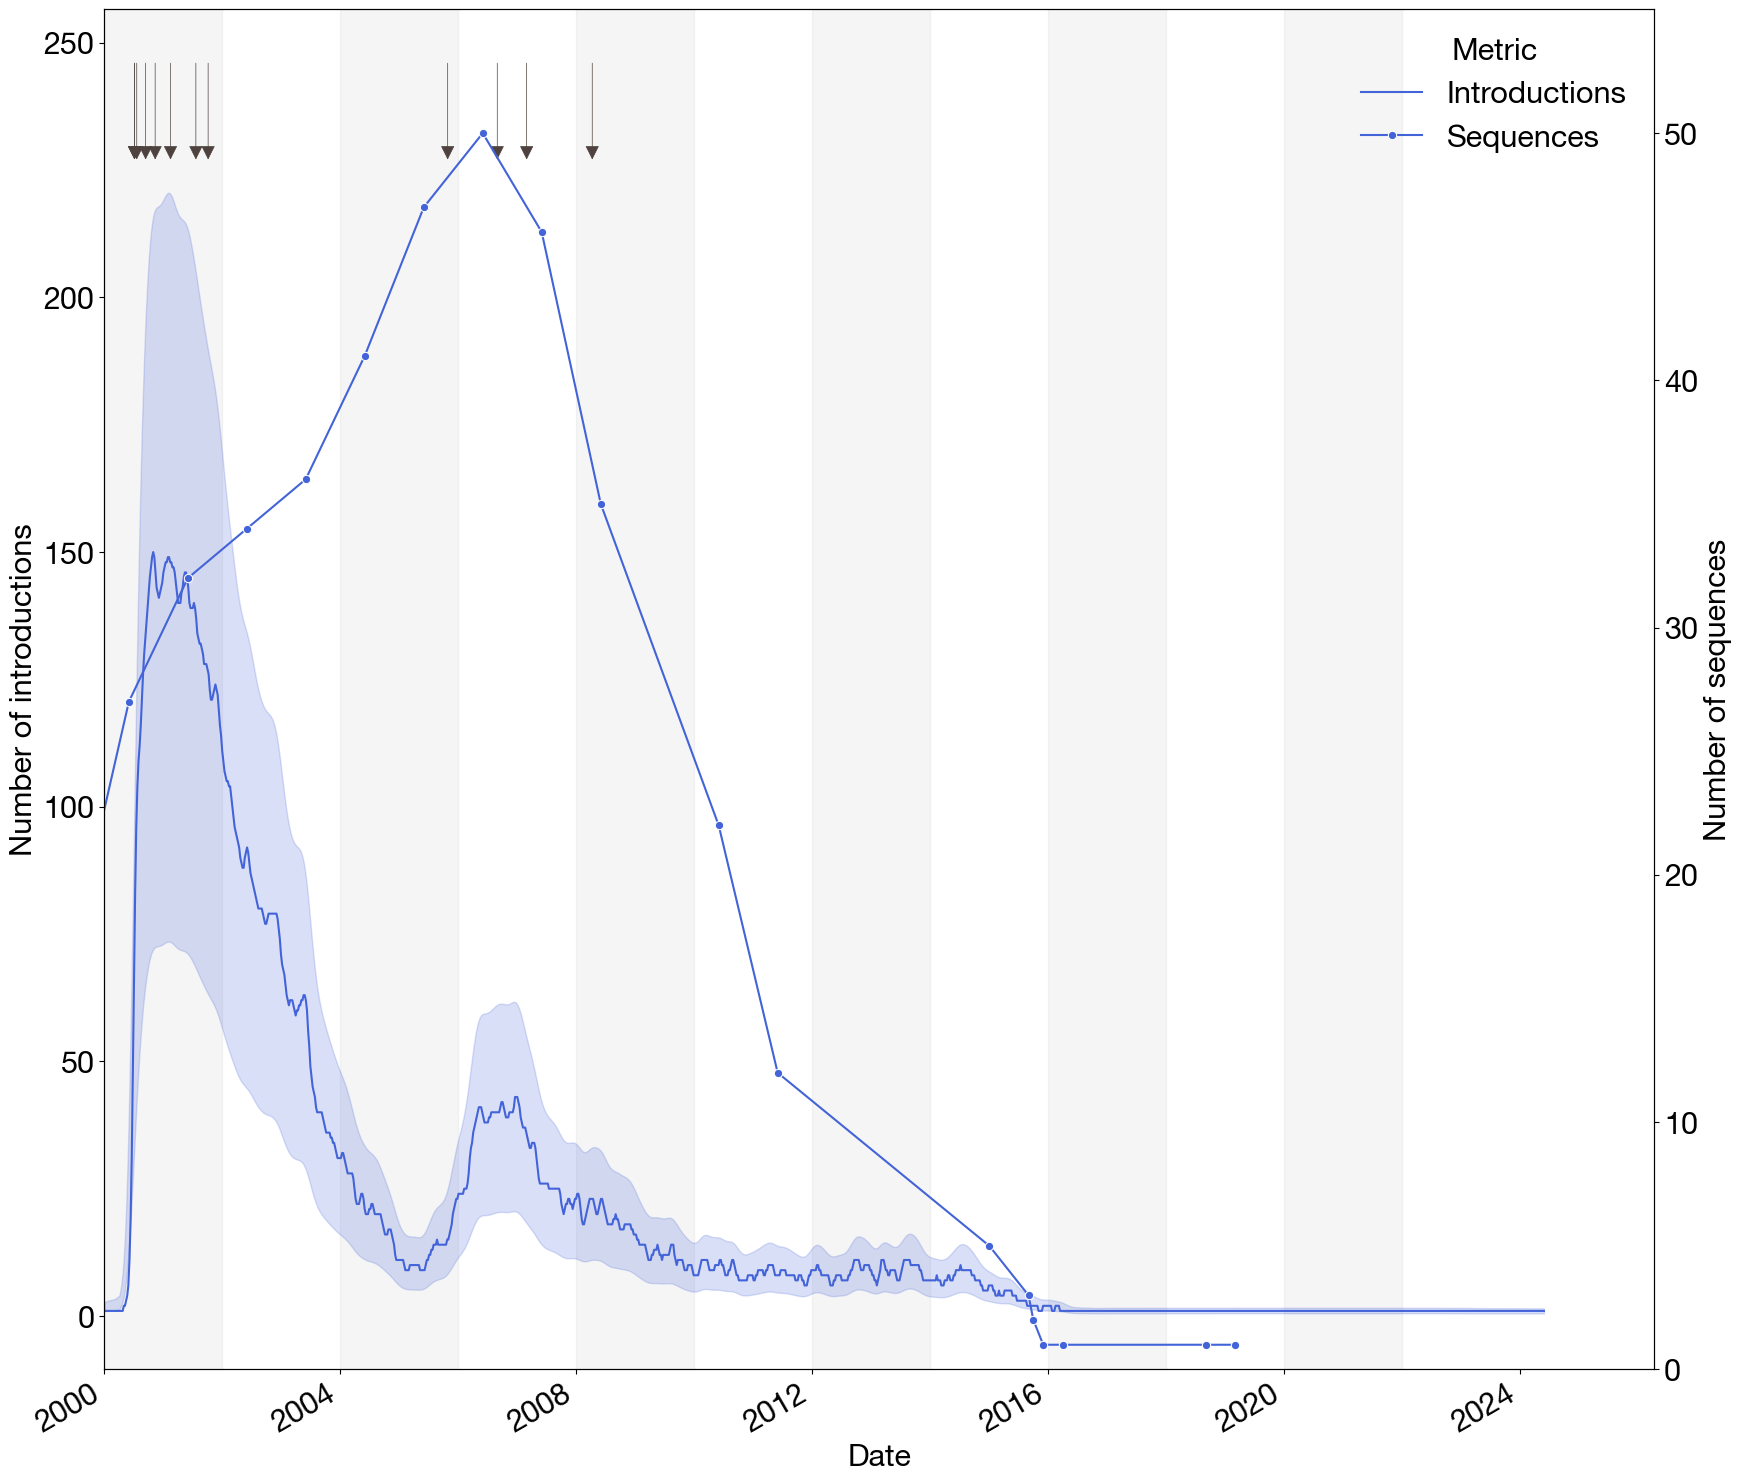

Spearman ρ = 0.67 (p = 0.002)


In [9]:
import pandas as pd
import numpy as np
import math
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from scipy.stats import spearmanr, pearsonr

mrsd = ll.mostRecent
tmrca = mrsd - ll.treeHeight

venezuela_color = '#4363d8'


# ——— FILE PATHS —————————————————————————————————————————————
BASE_DIR = Path('/Users/ricardorivero/Documents/DENV/2024/D3')
SEQ_TSV     = BASE_DIR / 'Data/Venezuela_colDates.tsv'
JUMP_FILE   = BASE_DIR / 'run2/MarkovJumps_D3_C2.txt'
FIG_OUT     = BASE_DIR / 'Figures/MarkovIntroductions.{ext}'

# ——— HELPERS ——————————————————————————————————————————————

def decimal_year_to_date(decimal_year):
    """
    Convert a decimal year (e.g. 2020.25) to a pd.Timestamp,
    returning NaT if input is NaN or None.
    """
    if pd.isna(decimal_year) or (isinstance(decimal_year, float) and math.isnan(decimal_year)):
        return pd.NaT

    # integer part → year
    year = int(decimal_year)
    # fractional part → days into that year (accounting for leap years)
    frac = decimal_year - year
    days_in_year = 366 if pd.Timestamp(year,1,1).is_leap_year else 365
    days = int(round(frac * days_in_year))
    
    return pd.Timestamp(f"{year}-01-01") + pd.Timedelta(days=days)

def parse_collection_date(s):
    """Parse 'YYYY', 'YYYY-MM' or 'YYYY-MM-DD'; else NaT."""
    if pd.isna(s) or str(s).strip().lower() == 'unknown':
        return pd.NaT
    parts = str(s).split('-')
    try:
        if len(parts) == 1:
            return pd.to_datetime(f"{parts[0]}-06-01")
        if len(parts) == 2:
            return pd.to_datetime(f"{parts[0]}-{parts[1]}-01")
        return pd.to_datetime(s, format='%Y-%m-%d', errors='coerce')
    except Exception:
        return pd.NaT

def week_start_series(dts):
    """Return the Monday of each date in Series dts."""
    return dts - pd.to_timedelta(dts.dt.dayofweek, unit='d')

# You need to have defined `mrsd`, `tmrca` and `decimal_year_to_date` already
# from your tree object (ll).

# ——— LOAD & PREPROCESS SEQUENCE METADATA ————————————————————————
df_seq = (
    pd.read_csv(SEQ_TSV, sep='\t')
      .assign(
         Collection_date = lambda d: d['Collection date'].apply(parse_collection_date),
         Submission_date = lambda d: pd.to_datetime(d['Submission date'], errors='coerce')
      )
      .dropna(subset=['Collection_date','Submission_date'])
)
df_seq['lag'] = (df_seq['Submission_date'] - df_seq['Collection_date']).dt.days
df_seq = df_seq.loc[df_seq['lag'] >= 0]

# weekly & monthly counts
df_seq['week']  = week_start_series(df_seq['Collection_date'])
df_seq['month'] = df_seq['Collection_date'].dt.to_period('M').dt.to_timestamp()

weekly_seq = df_seq.groupby('week').size().sort_index()
monthly_seq = df_seq.groupby('month').size().sort_index()
introduction_dates = pd.to_datetime(introduction_dates)

# ——— LOAD & PREPROCESS MARKOV JUMPS ——————————————————————————
df_j = pd.read_csv(JUMP_FILE, sep=None, engine='python')  # auto‐detect sep
df_j['time'] = pd.to_numeric(df_j['time'], errors='coerce')
# 1) compute decimal years since most‐recent sampling date
df_j['decimal_since_mrsd'] = mrsd - df_j['time']

# 2) elementwise convert to Timestamp, safely handling NaNs
df_j['date'] = df_j['decimal_since_mrsd'].apply(decimal_year_to_date)

# 3) filter out anything before your tMRCA
df_j = df_j.loc[df_j['decimal_since_mrsd'] >= tmrca]

# 4) continue with your downstream filtering & grouping
df_j = df_j[
    (df_j['from'] == 'Venezuela') &
    (df_j['to']   == 'Colombia')
]
df_j['week'] = week_start_series(df_j['date'])

jump_counts = (
    df_j.groupby('week').size()
       .sort_index()
       .reset_index(name='count')
)

# ——— SMOOTHING & ERRORS —————————————————————————————————————
sigma_main = 2
sigma_err  = 5

jump_counts['smoothed']   = gaussian_filter1d(jump_counts['count'], sigma=sigma_main)
upper = gaussian_filter1d(jump_counts['count'] * 1.5, sigma=sigma_err)
lower = gaussian_filter1d(jump_counts['count'] * 0.5, sigma=sigma_err)

monthly_seq = monthly_seq.reset_index(name='counts')
monthly_seq['smoothed'] = gaussian_filter1d(monthly_seq['counts'], sigma=sigma_main)

# ——— PLOTTING ——————————————————————————————————————————————
fig, ax1 = plt.subplots(figsize=(20, 20))

# Introductions
sns.lineplot(x='week', y='smoothed', data=jump_counts, ax=ax1, label='Introductions', color = venezuela_color)
ax1.fill_between(jump_counts['week'], upper, lower, alpha=0.2, color = venezuela_color)
ax1.set_ylabel('Number of introductions')

# Shaded 4-year spans
for start_year in range(2000, 2024, 4):
    ax1.axvspan(pd.Timestamp(start_year,1,1),
                pd.Timestamp(start_year+2,1,1),
                color='k', alpha=0.04, zorder=0)

# Sequence counts on secondary axis
ax2 = ax1.twinx()
sns.lineplot(x='month', y='smoothed', data=monthly_seq, ax=ax2,
             label='Sequences', marker='o', color = venezuela_color, legend=False)
ax2.set_ylabel('Number of sequences')
ax2.set_ylim(0, monthly_seq['smoothed'].max() * 1.1)
ax1.set_xlim(left=pd.Timestamp('2000-01-01'))
ax1.set_xlabel('Date')
fig.autofmt_xdate()

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2,
           l1 + l2,
           loc='upper right',
           ncol=1,
           frameon=False,
           title='Metric')

# Annotations (if you have a list `introduction_dates`)

max_y = ax1.get_ylim()[1]
y_start = max_y + 15
y_end = max_y - 5

ax1.set_ylim(ax1.get_ylim()[0], y_start + 10)

for date in introduction_dates:
    ax1.annotate("",
                xy=(date, y_end),
                xytext=(date, y_start),
                arrowprops=dict(arrowstyle="-|>",
                                connectionstyle="arc3", color='#4d423d', lw=0.5),
                )


# ——— SAVE ————————————————————————————————————————————————
for ext in ('jpeg','svg'):
    fig.savefig(str(FIG_OUT).format(ext=ext),
                dpi=1200, bbox_inches='tight')
plt.show()

# ——— CORRELATION ANALYSIS ——————————————————————————————
# Align weekly counts
df_merge = (
    jump_counts[['week','count']]
      .merge(weekly_seq.rename('seq_count').reset_index(), on='week')
)

rho, p_s = spearmanr(df_merge['count'], df_merge['seq_count'])
r,   p_p = pearsonr(df_merge['count'], df_merge['seq_count'])

print(f"Spearman ρ = {rho:.2f} (p = {p_s:.3f})")